# **Mineral Prospectivity Project**
## 02b National Geochemical Database (NGDB) exploratory data analysis

goals:\
-create plots and maps to investigate distributions, correlations and spatial trends

### Part 1. import packages and identify local directory
a. import packages needed for data loading and analysis

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

sns.set_theme(style='whitegrid')

data_path = "/Users/adbyerly/prospectivity_model/data/processed/"

### Part 2. load processed data

In [5]:
# csv - load all geochemical files from the processed folder into a dictionary
files = glob.glob(data_path + "NGDB/*.csv")
ngdb_dfs_processed={}

for file in files:
    name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file, low_memory=False)
    ngdb_dfs_processed[name] = df

ngdb_dfs_processed.keys()
print(ngdb_dfs_processed['Rock_Data'].head())

   lab_id job_id         submitter    date_sub field_id state        country  \
0  AAV161   HM42  Gott, Garland B.  19660721.0    CD008    ID  United States   
1  AAV162   HM42  Gott, Garland B.  19660721.0   CD008A    ID  United States   
2  AAV163   HM42  Gott, Garland B.  19660721.0    CD009    ID  United States   
3  AAV164   HM42  Gott, Garland B.  19660721.0   CD009A    ID  United States   
4  AAV165   HM42  Gott, Garland B.  19660721.0    CD010    ID  United States   

  original_datum spheroid  latitude  ...  struct_src dep_envirn source_rk  \
0          NAD27      NaN  47.47778  ...         NaN        NaN       NaN   
1          NAD27      NaN  47.47778  ...         NaN        NaN       NaN   
2          NAD27      NaN  47.47667  ...         NaN        NaN       NaN   
3          NAD27      NaN  47.47667  ...         NaN        NaN       NaN   
4          NAD27      NaN  47.47556  ...         NaN        NaN       NaN   

  metamrphsm facies_grd prep mesh_size Unnamed: 31  \
0 

In [6]:
# examine processed dataframes

# for name, df in ngdb_dfs_processed.items():
#     print(name)
#     print(df.head())
#     print(df.columns)
#     print(df.shape)
#     print("-" * 25)

### Part 3. investigate data and document observations

a. start with the "Rock Data" dataframe which contains information about the samples

In [7]:
# set variable for this table
rockdata = ngdb_dfs_processed['Rock_Data']

print(rockdata.head())
print(rockdata.columns)
print(rockdata.dtypes)
print(rockdata.shape)

   lab_id job_id         submitter    date_sub field_id state        country  \
0  AAV161   HM42  Gott, Garland B.  19660721.0    CD008    ID  United States   
1  AAV162   HM42  Gott, Garland B.  19660721.0   CD008A    ID  United States   
2  AAV163   HM42  Gott, Garland B.  19660721.0    CD009    ID  United States   
3  AAV164   HM42  Gott, Garland B.  19660721.0   CD009A    ID  United States   
4  AAV165   HM42  Gott, Garland B.  19660721.0    CD010    ID  United States   

  original_datum spheroid  latitude  ...  struct_src dep_envirn source_rk  \
0          NAD27      NaN  47.47778  ...         NaN        NaN       NaN   
1          NAD27      NaN  47.47778  ...         NaN        NaN       NaN   
2          NAD27      NaN  47.47667  ...         NaN        NaN       NaN   
3          NAD27      NaN  47.47667  ...         NaN        NaN       NaN   
4          NAD27      NaN  47.47556  ...         NaN        NaN       NaN   

  metamrphsm facies_grd prep mesh_size Unnamed: 31  \
0 

In [8]:
# general observations about sample quantity and locations

print ('There are ' + str(len(rockdata)) + ' samples.')

# print(rockdata['depth'].nunique())
# print(rockdata['depth'].unique())

# observation --------
print('All samples are effectively from the surface.')

print('Samples come from ' + str(rockdata['locat_desc'].nunique()) + ' locations.')

There are 26521 samples.
All samples are effectively from the surface.
Samples come from 214 locations.


<StringArray>
['rock']
Length: 1, dtype: str
<StringArray>
['metamorphic', nan, 'sedimentary', 'igneous', 'unidentified']
Length: 5, dtype: str
xndryclass
igneous         13095
metamorphic      6249
sedimentary      4527
NaN              2392
unidentified      258
Name: count, dtype: int64


<Axes: xlabel='xndryclass'>

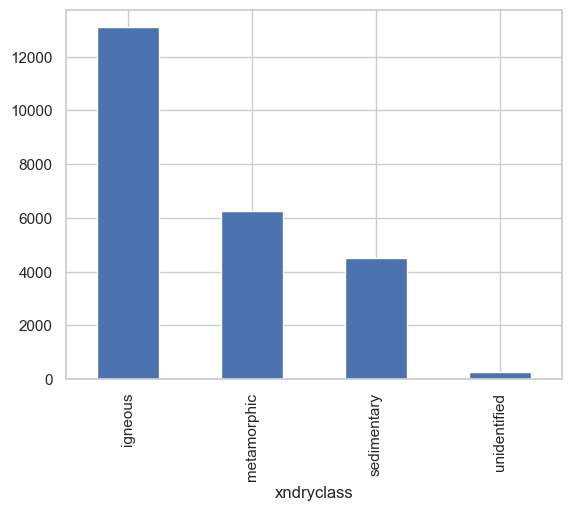

In [9]:
# identify types of rocks



# -------- these don't contain apparently useful information
# print(rockdata['source_rk'].nunique())
# print(rockdata['source_rk'].unique())
# print(rockdata['source_rk'].value_counts(dropna=False))

# print(rockdata['sample_src'].nunique())
# print(rockdata['sample_src'].unique())

# print(rockdata['metamrphsm'].nunique())
# print(rockdata['metamrphsm'].unique())
# -------- these don't contain apparently useful information



# 'xnddryclass' feature contains information about the rock type
print(rockdata['primeclass'].unique())
print(rockdata['xndryclass'].unique())
print(rockdata['xndryclass'].value_counts(dropna=False))

rockdata['xndryclass'].value_counts().plot(kind='bar')

In [10]:
# examine ages of igneous rocks

mask = rockdata['xndryclass'] == 'igneous'
igneous = rockdata[mask]

print(igneous['geol_age'].nunique())
print(igneous['geol_age'].unique().tolist())

80
[nan, 'Cretaceous', 'Precambrian undifferentiated', 'tertiary undifferentiated', 'cretaceous', 'eocene', 'jurassic', 'mesozoic undifferentiated', 'Tertiary', 'Quaternary', 'tertiary', 'late precambrian', 'cretaceous--tertiary', 'mesozoic', 'Middle Precambrian', 'Unknown', 'Eocene', 'Late Precambrian', 'pliocene--quaternary', 'pliocene--pleistocene', 'pleistocene', 'holocene', 'quaternary', 'pliocene', 'miocene', 'pennsylvanian--triassic', 'miocene--pliocene', 'miocene--pleistocene', 'paleocene--miocene', 'precambrian undifferentiated', 'cretaceous--eocene', 'mesozoic--tertiary', 'precambrian undiff--eocene', 'paleozoic', 'tertiary--quaternary', 'jurassic--cretaceous', 'eocene--oligocene', 'ordovician--silurian', 'oligocene--miocene', 'precambrian undiff--tertiary', 'permian--jurassic', 'permian', 'permian--triassic', 'oligocene', 'late precambrian--paleozoic', 'late precambrian--paleocene', 'cretaceous--miocene', 'ordovician', 'late precambrian--cretaceous', 'late precambrian--eocen

In [11]:
print(igneous['spec_name'].unique().tolist())
print(igneous.columns)

['mafic', 'monzonite', 'granite', 'felsic', 'dacite', 'porphyry', 'felsite', 'adamellite', 'latite', 'tonalite', 'rhyolite', 'granodiorite', 'quartz', 'intermediate', 'andesite', 'welded tuff', 'aplite', 'pegmatite', 'tuff', 'basalt', 'ultramafic', 'feldspathoidal', nan, 'rhyodacite', 'quartz diorite', 'diorite', 'quartz monzonite', 'felsic igneous', 'gabbro', 'obsidian', 'ash', 'syenite', 'pumice', 'olivine basalt', 'diabase', 'quartz latite', 'TUFF', 'WELDED TUFF', 'volcanic glass', 'unknown', 'alaskite', 'carbonatite', 'RHYODACITE', 'FELSITE', 'PERLITE', 'PUMICE', 'RHYOLITE', 'pyroxenite', 'amphibolite', 'BASALT', 'GRANODIORITE', 'trachyte', 'lamprophyre', 'DIORITE', 'alkalic', 'BRECCIA', 'PEGMATITE', 'gneiss', 'ANDESITE', 'DACITE', 'SCORIA', 'VITROPHYRE', 'GABBRO', 'monzodiorite', 'QUARTZ', 'TONALITE', 'MONZONITE', 'trap', 'hornblendite', 'syenite/nepheline', 'malignite', 'minette', 'leucogranite', 'augen gneiss', 'AUGEN GNEISS', 'orthogneiss', 'schist', 'syenogranite', 'breccia']


b. major element chemistry in igneous subset

In [12]:
# filter chemical analysis tables to igenous rocks

igneous_id = igneous['lab_id']
igneous_chem = {}

for d, df in ngdb_dfs_processed.items():
    igneous_chem[d] = df[df['lab_id'].isin(igneous_id)].copy()  # copy df, filter to igneous rock primary key values 


print(igneous_chem.keys())

dict_keys(['Rock_Data', 'XRF', 'Unknown_chem', 'Other_chem', 'ES', 'ICPAES', 'ICPMS', 'Major_element', 'NAA'])


In [13]:
# examine direct gold concentration measurements
# from metadata, these are the geochemical data tables that contain direct gold measurements:

# - NAA
# - ICPAES
# - ICPMS
# - ES

['lab_id', 'capct_na', 'capct_naq', 'fepct_na', 'fepct_naq', 'fe_cvpct', 'kpct_na', 'kpct_naq', 'k_cvpct', 'napct_na', 'napct_naq', 'na_cvpct', 'asppm_na', 'asppm_naq', 'as_cvpct', 'auppb_na', 'auppb_naq', 'au_cvpct', 'bappm_na', 'bappm_naq', 'ba_cvpct', 'brppm_na', 'brppm_naq', 'cdppm_na', 'cdppm_naq', 'cd_cvpct', 'ceppm_na', 'ceppm_naq', 'ce_cvpct', 'coppm_na', 'coppm_naq', 'co_cvpct', 'crppm_na', 'crppm_naq', 'cr_cvpct', 'csppm_na', 'csppm_naq', 'cs_cvpct', 'cuppm_na', 'cuppm_naq', 'cu_cvpct', 'dyppm_na', 'dyppm_naq', 'dy_cvpct', 'euppm_na', 'euppm_naq', 'eu_cvpct', 'gappm_na', 'gappm_naq', 'gdppm_na', 'gdppm_naq', 'gd_cvpct', 'hfppm_na', 'hfppm_naq', 'hf_cvpct', 'hgppm_na', 'hgppm_naq', 'hg_cvpct', 'hoppm_na', 'hoppm_naq', 'ho_cvpct', 'irppb_na', 'irppb_naq', 'ir_cvpct', 'lappm_na', 'lappm_naq', 'la_cvpct', 'luppm_na', 'luppm_naq', 'lu_cvpct', 'mnppm_na', 'mnppm_naq', 'mn_cvpct', 'moppm_na', 'moppm_naq', 'ndppm_na', 'ndppm_naq', 'nd_cvpct', 'nippm_na', 'nippm_naq', 'ni_cvpct', 'rbp

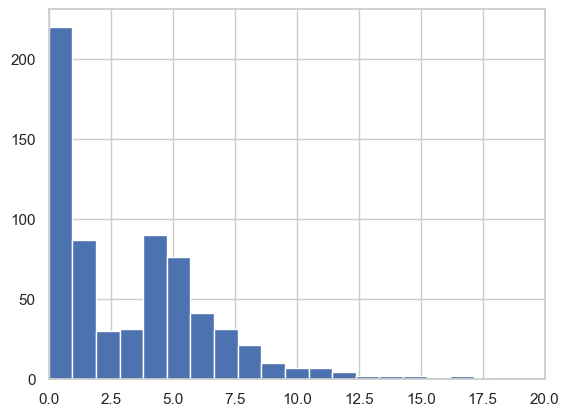

In [14]:
# NAA

NAA = igneous_chem['NAA']
print(NAA.columns.tolist())
print(NAA.columns[NAA.columns.str.contains('au')])
au = NAA['auppb_na']

print(au.describe())
plt.hist(au, range = (0,20), bins='auto')
plt.xlim(0, 20)
plt.show()

In [15]:
# identify columns for elements that may occur with gold
# Silver (Ag), Tellurium (Te), Copper (Cu), Mercury (Hg), Cobalt (Co), Antimony (Sb), Arsenic (As), Lead (Pb), Zinc (Zn)

print('Relevant column names for pathfinder elements:')
# Silver (Ag): 
print(NAA.columns[NAA.columns.str.contains('ag')]) # no relevant columns

#Tellurium (Te):
print(NAA.columns[NAA.columns.str.contains('te')]) # no relevant columns

# Copper (Cu):
print(NAA.columns[NAA.columns.str.contains('cu')])

# Mercury (Hg):
print(NAA.columns[NAA.columns.str.contains('hg')])

# Cobalt (Co): 
print(NAA.columns[NAA.columns.str.contains('co')])

# Antimony (Sb):
print(NAA.columns[NAA.columns.str.contains('sb')])

# Arsenic (As):
print(NAA.columns[NAA.columns.str.contains('as')])

# Lead (Pb):
print(NAA.columns[NAA.columns.str.contains('pb')]) # no relevant columns

# Zinc (Zn):
print(NAA.columns[NAA.columns.str.contains('zn')])


# create dataframe that is a subset including only the relevant columns
pathfinders = NAA[
    ['lab_id',
     'auppb_na',
     'cuppm_na',
     'hgppm_na',
     'coppm_na',
     'sbppm_na',
     'asppm_na',
     'znppm_na']
    ]

print(pathfinders.head())
print(pathfinders.shape)

Relevant column names for pathfinder elements:
Index([], dtype='str')
Index([], dtype='str')
Index(['cuppm_na', 'cuppm_naq', 'cu_cvpct'], dtype='str')
Index(['hgppm_na', 'hgppm_naq', 'hg_cvpct'], dtype='str')
Index(['coppm_na', 'coppm_naq', 'co_cvpct'], dtype='str')
Index(['sbppm_na', 'sbppm_naq', 'sb_cvpct'], dtype='str')
Index(['asppm_na', 'asppm_naq', 'as_cvpct'], dtype='str')
Index(['auppb_na', 'auppb_naq', 'irppb_na', 'irppb_naq'], dtype='str')
Index(['znppm_na', 'znppm_naq', 'zn_cvpct'], dtype='str')
     lab_id  auppb_na  cuppm_na  hgppm_na  coppm_na  sbppm_na  asppm_na  \
21  C176401       NaN       NaN       NaN     0.350    0.0629     0.527   
22  C176402       NaN       NaN       NaN    17.400    0.0271     0.246   
23  C176403       0.1       NaN       NaN    17.200    0.0464     0.642   
26  C176411       0.1       NaN       NaN     0.476    0.0677     0.227   
27  C176412       NaN       NaN       NaN     8.610    0.0733     0.267   

    znppm_na  
21      10.8  
22     

In [16]:
# join pathfinders dataframe with location data for samples

pathfinders_loc = pathfinders.merge(rockdata[['lab_id', 'geometry']], on = 'lab_id', how = 'inner')
print(pathfinders_loc.head())

print(pathfinders_loc.columns)

    lab_id  auppb_na  cuppm_na  hgppm_na  coppm_na  sbppm_na  asppm_na  \
0  C176401       NaN       NaN       NaN     0.350    0.0629     0.527   
1  C176402       NaN       NaN       NaN    17.400    0.0271     0.246   
2  C176403       0.1       NaN       NaN    17.200    0.0464     0.642   
3  C176411       0.1       NaN       NaN     0.476    0.0677     0.227   
4  C176412       NaN       NaN       NaN     8.610    0.0733     0.267   

   znppm_na                                     geometry  
0      10.8  POINT (549643.3904960516 4966000.348110897)  
1      72.0  POINT (549754.4392059512 4965846.793228507)  
2      92.8  POINT (549754.4392059512 4965846.793228507)  
3      36.3  POINT (588531.4228793064 4959290.827459483)  
4      84.4    POINT (583978.985967387 4959476.39124474)  
Index(['lab_id', 'auppb_na', 'cuppm_na', 'hgppm_na', 'coppm_na', 'sbppm_na',
       'asppm_na', 'znppm_na', 'geometry'],
      dtype='str')


In [17]:
pathfinders_loc.describe()
# drop copper and mercury, there are no data
# pathfinders_loc.drop(columns=['cuppm_na', 'hgppm_na'], inplace=True)

,auppb_na,cuppm_na,hgppm_na,coppm_na,sbppm_na,asppm_na,znppm_na
count,688.000000,0.0,0.0,1062.000000,940.000000,596.000000,1029.000000
mean,45.122474,NaN,NaN,18.152614,146.137673,3.822138,100.918212
std,879.972261,NaN,NaN,21.829920,1878.467563,28.644840,276.750347
min,0.020000,NaN,NaN,0.029000,0.010000,0.096000,2.300000
25%,0.667500,NaN,NaN,1.480000,0.078000,0.500000,40.300000
50%,3.000000,NaN,NaN,6.495000,0.150000,0.775000,63.000000
75%,5.000000,NaN,NaN,34.500000,0.460250,1.582500,107.000000
max,23000.000000,NaN,NaN,122.000000,44200.000000,490.000000,5240.000000


### Part 4. explore correlations

/var/folders/5k/44z6_qv57sz8v3pzftxvfn4m0000gn/T/ipykernel_24798/1129520631.py:13: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 1000)


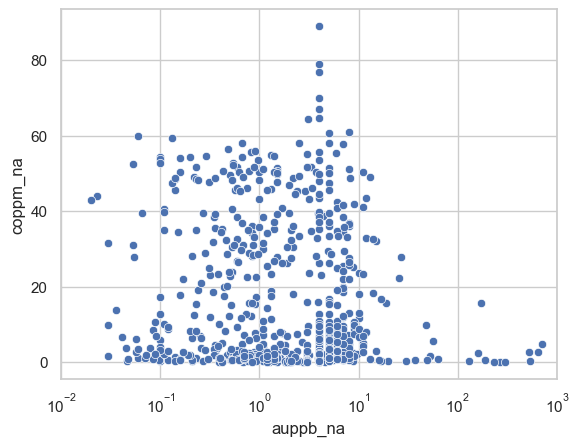

In [30]:
# linear correlations?

# gold and cobalt

fig, ax = plt.subplots()
sns.scatterplot(
    data=pathfinders_loc,
    x='auppb_na',
    y='coppm_na',
    ax=ax
)
ax.set_xscale('log')
plt.xlim(0, 1000)
plt.show()

/var/folders/5k/44z6_qv57sz8v3pzftxvfn4m0000gn/T/ipykernel_24798/1770538721.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 5)


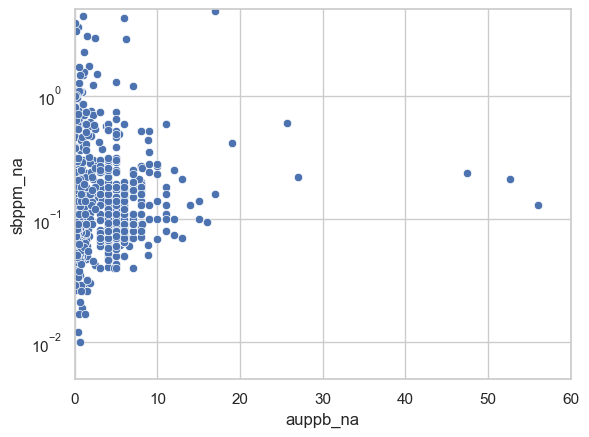

In [43]:
# linear correlations?

# gold and antimony

fig, ax = plt.subplots()
sns.scatterplot(
    data=pathfinders_loc,
    x='auppb_na',
    y='sbppm_na',
    ax=ax
)
ax.set_yscale('log')
plt.ylim(0, 5)
plt.xlim(0, 60)
plt.show()

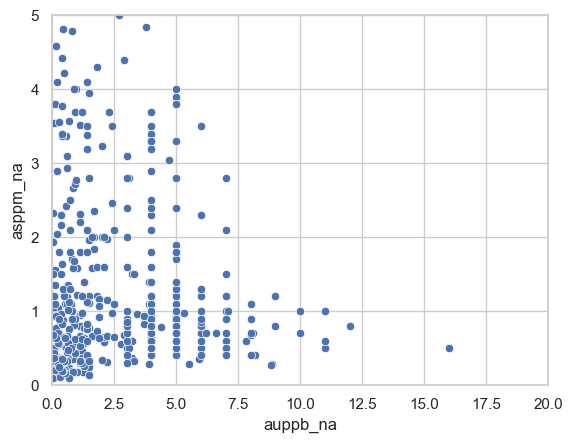

In [48]:
# linear correlations?

# gold and arsenic

fig, ax = plt.subplots()
sns.scatterplot(
    data=pathfinders_loc,
    x='auppb_na',
    y='asppm_na',
    ax=ax
)
# ax.set_yscale('log')
plt.ylim(0, 5)
plt.xlim(0, 20)
plt.show()

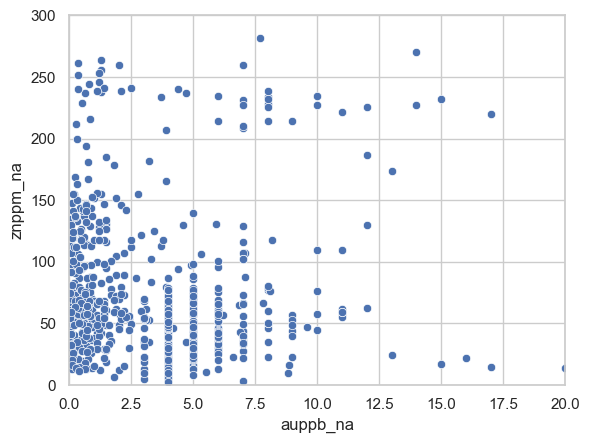

In [54]:
# linear correlations?

# gold and zinc

fig, ax = plt.subplots()
sns.scatterplot(
    data=pathfinders_loc,
    x='auppb_na',
    y='znppm_na',
    ax=ax
)
# ax.set_yscale('log')
plt.ylim(0, 300)
plt.xlim(0, 20)
plt.show()

array([[<Axes: title={'center': 'auppb_na'}>,
        <Axes: title={'center': 'coppm_na'}>],
       [<Axes: title={'center': 'sbppm_na'}>,
        <Axes: title={'center': 'asppm_na'}>],
       [<Axes: title={'center': 'znppm_na'}>, <Axes: >]], dtype=object)

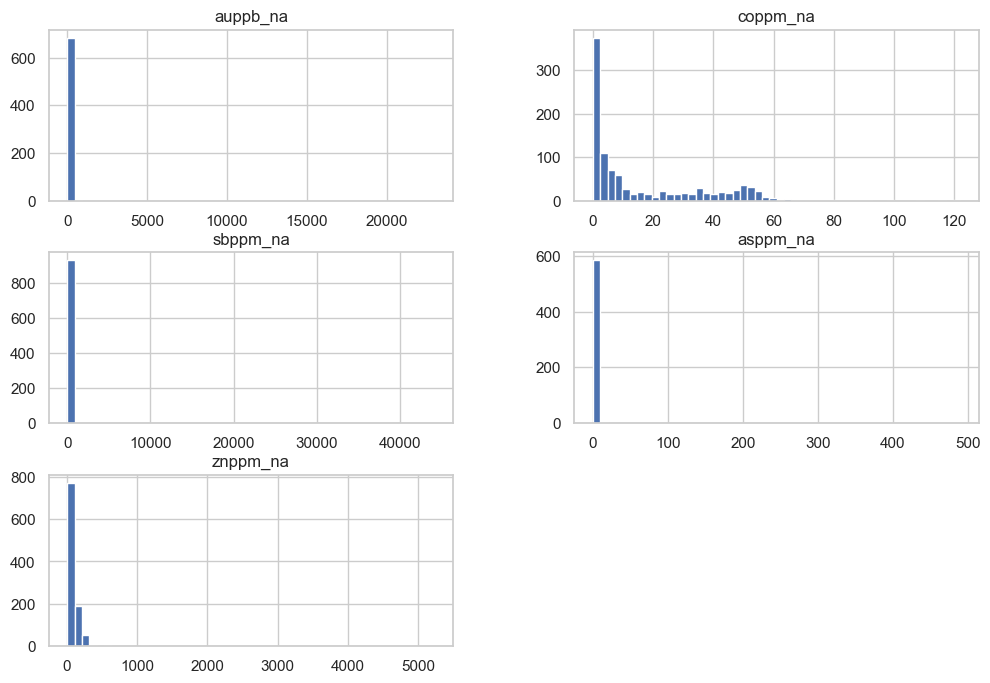

In [56]:
# Distribution check — geochemical data is almost always log-normal

elements_of_interest = ['auppb_na', 'coppm_na', 'sbppm_na', 'asppm_na', 'znppm_na']

pathfinders_loc[elements_of_interest].hist(bins=50, figsize=(12, 8))

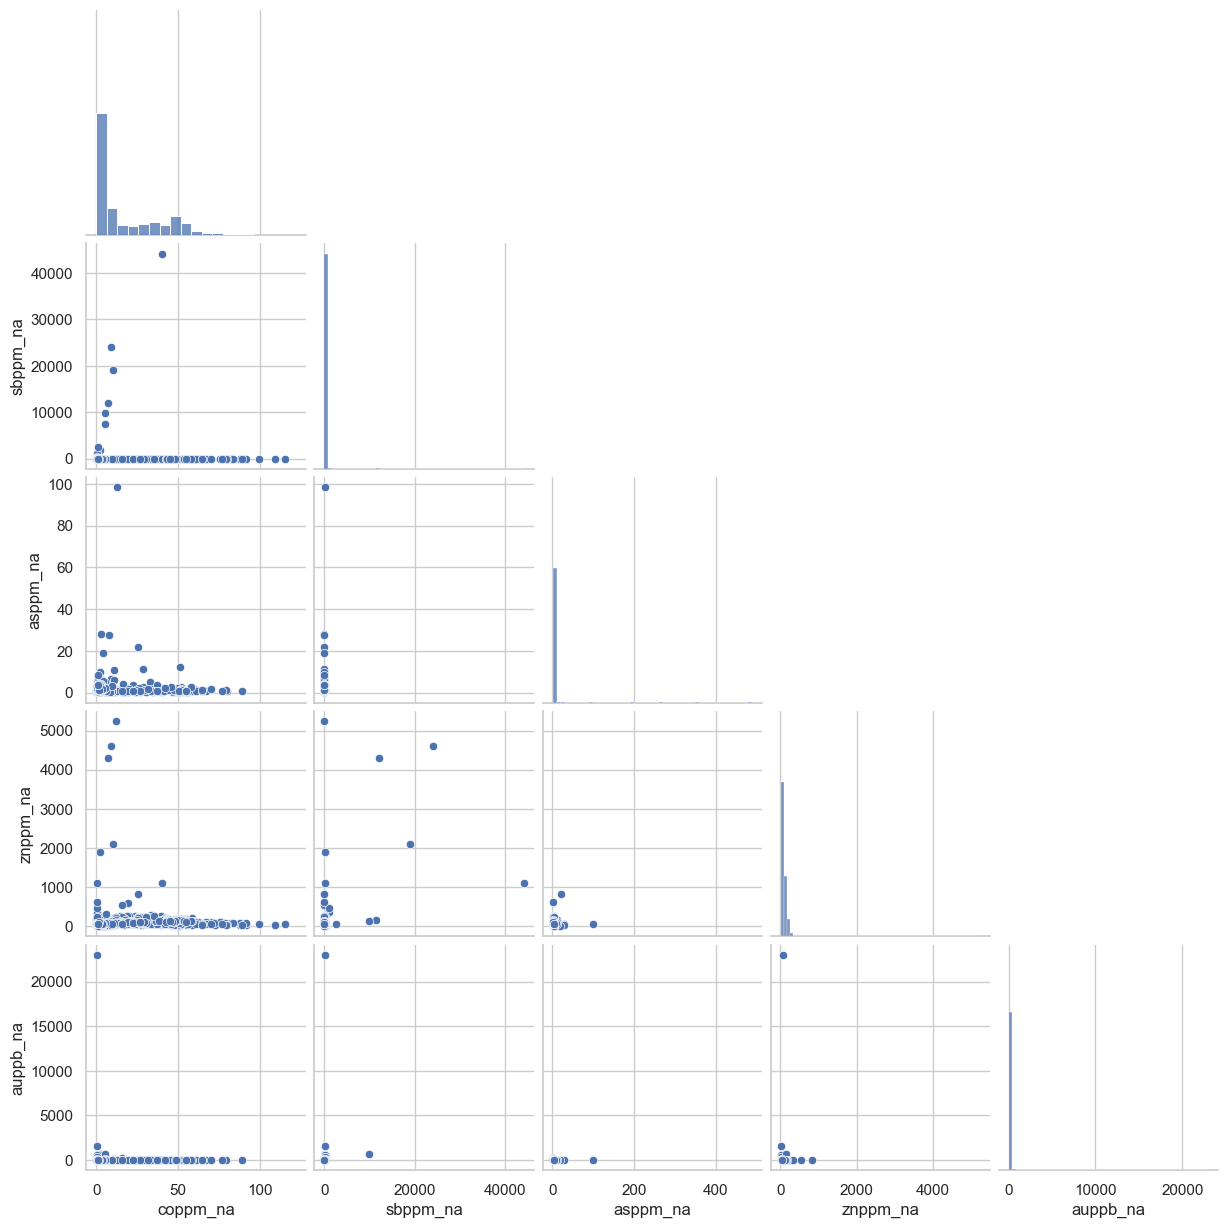

In [57]:
# Pairplots
target = 'auppb_na'
predictors = ['coppm_na', 'sbppm_na', 'asppm_na', 'znppm_na']
sns.pairplot(pathfinders_loc[predictors + [target]], corner=True)

### Part 5. export data

In [19]:
# convert to geodataframe and export pathfinders dataframe
from shapely import wkt

pathfinders_loc["geometry"] = pathfinders_loc["geometry"].apply(
    lambda x: wkt.loads(x) if isinstance(x, str) else x
)

pathfinders_loc = gpd.GeoDataFrame(
    pathfinders_loc,
    geometry=pathfinders_loc["geometry"]
)

pathfinders_loc = pathfinders_loc.set_crs("EPSG:32611")
# print(pathfinders_loc.head())

pathfinders_loc.to_file(data_path + "/NGDB/ngdb_naa_pathfinders.geojson", driver = "GeoJSON")